# Course Work 1

## Exercise 1

In this exercise, you will implement the EM  algorithms for classification. Please read the instructions in the pdf provided in e-class.

# PART 1.1

\begin{align}
p(x) = \sum _{k=1}^{K} \pi_k \cdot \mathcal{N}(x|\mu_k, \Sigma_k)
\end{align}

\begin{align}
Where:
\end{align}

\begin{align}
\pi_k &: \text{component weight } k, \text{ with } \sum _{k=1}^{K} \pi_k = 1\\
\mu_k &: \text{component mean } k\\
\Sigma_k &: \text{component covariance matrix } k\\
\mathcal{N}(x|\mu_k, \Sigma_k) &: \text{density of the multivariate Gaussian}
\end{align}

In [20]:
# Here your ID: 201932
import numpy as np
import matplotlib.pyplot as plt #can be reeplaced by other libraries
import scipy.io
import pandas as pd
#is not allowed to use libraries besides the ones here besides reeplacing matplotlib

In [21]:
def verify_columns(df):
    columns = df.columns
    if 'label' in columns:
        feature_columns = [col for col in columns if col != 'label'][:5]
    else:
        feature_columns = columns
    return feature_columns

def split_data(df, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    train_indices = []
    test_indices = []

    for label in df['label'].unique():
        label_indices = df[df['label'] == label].index.to_numpy()
        np.random.shuffle(label_indices)
        
        n_test = int(len(label_indices) * test_size)
        test_indices.extend(label_indices[:n_test])
        train_indices.extend(label_indices[n_test:])
    
    df_train = df.loc[train_indices].reset_index(drop=True)
    df_test = df.loc[test_indices].reset_index(drop=True)
    return df_train, df_test

def create_dataframe(filename):
    mat = scipy.io.loadmat(filename)
    print("Keys: ", mat.keys())

    X_list = []
    y_list = []

    class_keys = [k for k in mat.keys() if k.startswith('C')]

    print("Clases encontradas:", class_keys)

    for idx, key in enumerate(sorted(class_keys)):
        class_data = mat[key]
        print(f"Clase {key} shape:", class_data.shape)

        labels = np.full(class_data.shape[0], idx)  # etiqueta numérica para cada clase

        X_list.append(class_data)
        y_list.append(labels)

    # Concatenar todos los datos y etiquetas
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)

    df = pd.DataFrame(X, columns=[f'x{i+1}' for i in range(X.shape[1])])
    df['label'] = y.astype(int)

    return df

df = create_dataframe('exercise1_2.mat')
df_train, df_test = split_data(df, test_size=0.2, random_state=42)
df_train, df_val = split_data(df_train, test_size=0.4, random_state=42)
print("Training set shape:", df_train.shape)
print("Validation set shape:", df_val.shape)
print("Test set shape:", df_test.shape)


Keys:  dict_keys(['__header__', '__version__', '__globals__', 'C0', 'C1'])
Clases encontradas: ['C0', 'C1']
Clase C0 shape: (5000, 2)
Clase C1 shape: (10000, 2)
Training set shape: (7200, 3)
Validation set shape: (4800, 3)
Test set shape: (3000, 3)


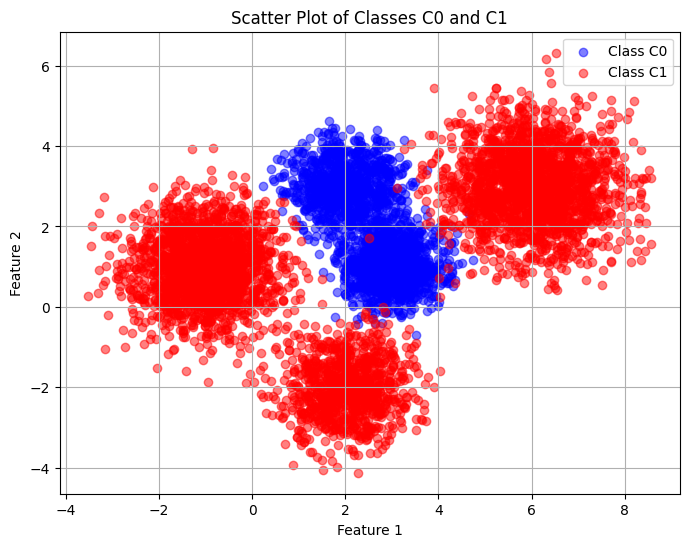

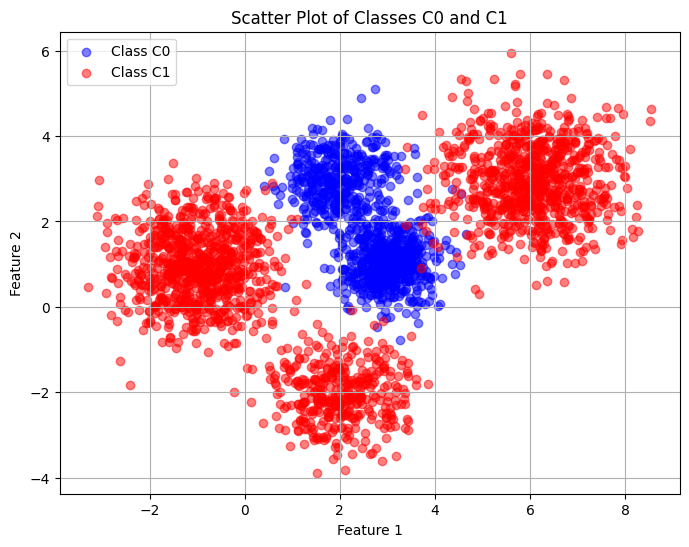

In [22]:
def plot_data(df):
    plt.figure(figsize=(8, 6))
    for label, color in zip([0, 1], ['blue', 'red']):
        subset = df[df['label'] == label]
        plt.scatter(subset['x1'], subset['x2'], color=color, label=f'Class C{label}', alpha=0.5)

    plt.title('Scatter Plot of Classes C0 and C1')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_data(df_train)
plot_data(df_test)

#### Step 1 (Expectation)

\begin{align}
\gamma(z_{nk}) = \frac{\pi_k \cdot \mathcal{N}(x_n | \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \cdot \mathcal{N}(x_n | \mu_j, \Sigma_j)}
\end{align}

In [23]:
def init_parameters(df, K=2):
    columns = verify_columns(df)
    X = df[columns].values
    N, D = X.shape
    print(N,D)

    # Here I find the best centroids 
    mu = []
    mu.append(X[np.random.randint(N)])
    
    for _ in range(1, K):
        distances = np.array([min([np.linalg.norm(x - m)**2 for m in mu]) for x in X])
        distances = np.maximum(distances, 1e-10)
        probabilities = distances / distances.sum()
       
        # Here I select the next center based on the probabilities
        next_center_idx = np.random.choice(N, p=probabilities)
        mu.append(X[next_center_idx])
    
    mu = np.array(mu)
    
    # Inicializated covariance like advice from the exercise
    cov = []
    for k in range(K):
        # Find closest points to each centroid
        distances_to_center = [np.linalg.norm(X - mu[k], axis=1)]
        closest_indices = np.argsort(distances_to_center[0])[:max(30, N//K)]
        X_closest = X[closest_indices]
        
        # Calculate covariance of nearest points
        subset_cov = np.cov(X_closest.T)
        
        if subset_cov.ndim == 0:
            subset_cov = np.eye(D) * np.var(X_closest)
        elif subset_cov.ndim == 1:
            subset_cov = np.diag(subset_cov)
        
        # Minor regularization to allow more flexibility   
        cov.append(subset_cov + np.eye(D) * 1e-6)
    
    pi = np.ones(K) / K
    return mu, cov, pi

In [24]:
def expectation_step(df, mu, cov, pi):
    columns = verify_columns(df)
    X = df[columns].values
    N, D = X.shape
    K = len(pi)

    # Initialize the responsibilities matrix
    gamma = np.zeros((N, K))

    for k in range(K):
        diff = X - mu[k]
        cov_reg = cov[k] + np.eye(D)*1e-6
        inv_cov = np.linalg.inv(cov_reg)
        det_cov = np.linalg.det(cov_reg)
        norm_const = 1. / np.sqrt((2 * np.pi) ** D * det_cov)
        exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
        gamma[:, k] = pi[k] * norm_const * np.exp(exponent)

    gamma /= gamma.sum(axis=1, keepdims=True)  # normalization

    return gamma


#### Step 2 (Maximization)


Update $\pi_k$, $\mu_k$, $\Sigma_k$ con base en $\gamma(z_{nk})$

\begin{align}

\mu_k = \frac{1}{N_k} \sum_n \gamma(z_{nk}) x_n \\

\Sigma_k = \frac{1}{N_k} \sum_n \gamma(z_{nk}) (x_n - \mu_k)(x_n - \mu_k)^T \\

\pi_k = \frac{N_k}{N}
\end{align}


Where

\begin{align}
N_k = \sum_n \gamma(z_{nk}) \\
\end{align}

In [25]:
def maximization_step(df, gamma):
    columns = verify_columns(df)
    X = df[columns].values
    N, D = X.shape
    K = gamma.shape[1]

    N_k = gamma.sum(axis=0)
    mu = np.zeros((K, D))
    cov = []

    for k in range(K):
        # Mean
        mu[k] = np.sum(gamma[:, k][:, None] * df[columns].values, axis=0) / N_k[k]
        
        # Covariance
        diff = X - mu[k]
        cov_k = (gamma[:, k][:, None] * diff).T @ diff / N_k[k]
        cov.append(cov_k)

    pi = N_k / N
    return mu, cov, pi

### Step 3 (Likelihood)


\begin{align}
\ln p(X|\mu, \Sigma, \pi) = \sum_{n=1}^{N} \ln \left\{ \sum_{k=1}^{K} \pi_k \mathcal{N}(x_n | \mu_k, \Sigma_k) \right\}
\end{align}

In [26]:
def compute_likelihood(X, mu, cov, pi):
    N, D = X.shape
    K = len(pi)
    likelihoods = np.zeros(N)

    for k in range(K):
        diff = X - mu[k] 
        cov_reg = cov[k] + np.eye(D) * 1e-6
        inv_cov = np.linalg.inv(cov_reg)
        det_cov = np.linalg.det(cov_reg)
        
        if det_cov <= 0:
            det_cov = 1e-6
        
        norm_const = 1. / np.sqrt((2 * np.pi) ** D * det_cov)
        exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
        exponent = np.clip(exponent, -500, 500)
        
        likelihoods += pi[k] * norm_const * np.exp(exponent)
        
    return np.log(np.maximum(likelihoods, 1e-6))

def plot_likelihood(ll_list, title='Log-Likelihood over iterations'):
    plt.figure(figsize=(14, 4))
    plt.plot(ll_list, marker='o')
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel("Log-likelihood")
    plt.grid(True)
    plt.show()

#### Accuracy_score, Precision_score, Recall_score

In [27]:
def accuracy_score(y_true, y_pred):
    correct = (y_true == y_pred).sum()
    total = len(y_true)
    return correct / total

def precision_score(y_true, y_pred):
    # Precision = TP / (TP + FP)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    if tp + fp == 0:
        return 0.0
    return tp / (tp + fp)

def recall_score(y_true, y_pred):
    # Recall = TP / (TP + FN)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    if tp + fn == 0:
        return 0.0
    return tp / (tp + fn)

#### TRAIN 

In [28]:
from matplotlib.patches import Ellipse

def plot_mean_snapshots(df, mu_snaps, 
                        cov_snaps, iter_labels,
                        sigma_levels=(1, 2)):
    n = len(mu_snaps)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5), constrained_layout=True)

    if n == 1:
        axes = [axes]

    # Colors for the Gaussian components
    K = mu_snaps[0].shape[0]          # Number of components
    distinct_colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    colors = distinct_colors[:K]

    for ax, mu, covs, it in zip(axes, mu_snaps, cov_snaps, iter_labels):
        ax.scatter(df['x1'], df['x2'], alpha=0.3, s=8, c='lightgray', label='Data')

        for k, (m, S, col) in enumerate(zip(mu, covs, colors)):
            ax.scatter(m[0], m[1], marker='x', s=150, c=col, 
                      linewidths=3, label=f'G{k} mean', zorder=5)  
            lam, vec = np.linalg.eigh(S)
            angle = np.degrees(np.arctan2(*vec[:, 1][::-1]))

            for s in sigma_levels:
                width, height = 2 * s * np.sqrt(lam)          
                ell = Ellipse(xy=m, width=width, height=height,
                              angle=angle, edgecolor=col, facecolor='none',
                              linewidth=2.5 if s == 1 else 1.5,
                              alpha=0.8 if s == 1 else 0.5,
                              linestyle='-' if s == 1 else '--')
                ax.add_patch(ell)

        ax.set_title(f'Iter {it}')
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)

    fig.suptitle('Evolution of means ans ellipses', fontsize=14)
    plt.show()

def train(df_class, K, max_iter=100, tol=1e-6, show_plot=True):
    columns = verify_columns(df_class)
    mu, cov, pi = init_parameters(df_class, K)
    prev_ll = -np.inf
    ll_list = []

    plot_iters = []
    mu_snapshots = []
    cov_snapshots = []

    for i in range(max_iter):
        gamma = expectation_step(df_class, mu, cov, pi)
        mu, cov, pi = maximization_step(df_class, gamma)

        # here i make the sum of the likelihoods
        individual_ll = compute_likelihood(df_class[columns], mu, cov, pi)
        ll = np.sum(individual_ll)
        ll_list.append(ll)
        
        if i % 50 == 0 or i == max_iter - 1:
            print(f"Iteration {i+1}, Log Likelihood: {ll}")
            plot_iters.append(i)
            mu_snapshots.append(mu.copy())
            cov_snapshots.append([c.copy() for c in cov])

        if i > 0 and abs(ll - prev_ll) < tol:
            print("Convergence reached.")
            break
        prev_ll = ll

    if show_plot:
        plot_mean_snapshots(df_class, mu_snapshots, cov_snapshots, plot_iters)
    
    return mu, cov, pi, ll_list


In [29]:
def predict_class(X, gmm0, gmm1):
    mu0, cov0, pi0 = gmm0
    mu1, cov1, pi1 = gmm1

    ll0 = compute_likelihood(X, mu0, cov0, pi0)
    ll1 = compute_likelihood(X, mu1, cov1, pi1)
    
    return (ll1 > ll0).astype(int).flatten()

def evaluate_predictions(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")

Training models for class 0
K0 = 1
2400 2
Iteration 1, Log Likelihood: -3337.3507207902203
Convergence reached.


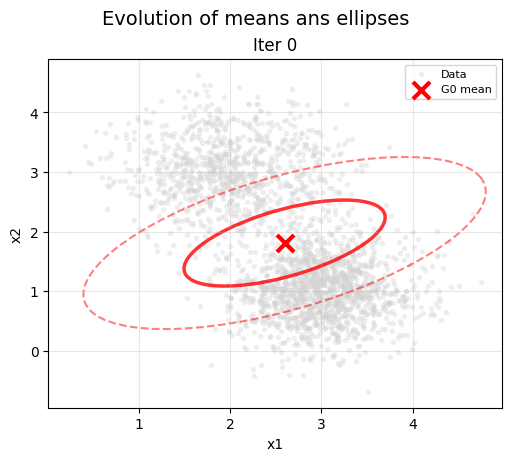

K0 = 2
2400 2
Iteration 1, Log Likelihood: -1341.830420295357
Convergence reached.


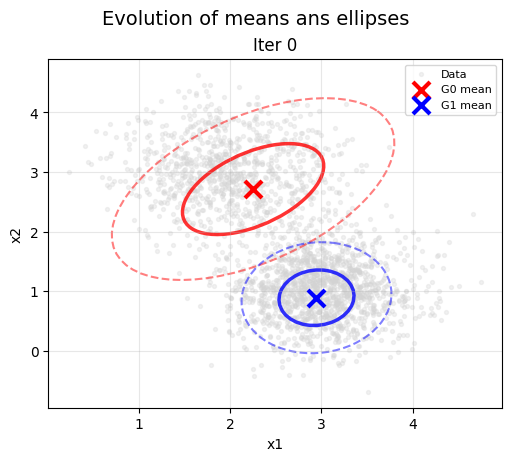

K0 = 3
2400 2
Iteration 1, Log Likelihood: -999.8007427796524
Iteration 51, Log Likelihood: -1072.6843673288095
Iteration 101, Log Likelihood: -1089.3854268557411
Iteration 151, Log Likelihood: -1095.6704586311264
Iteration 200, Log Likelihood: -1097.4267138633306


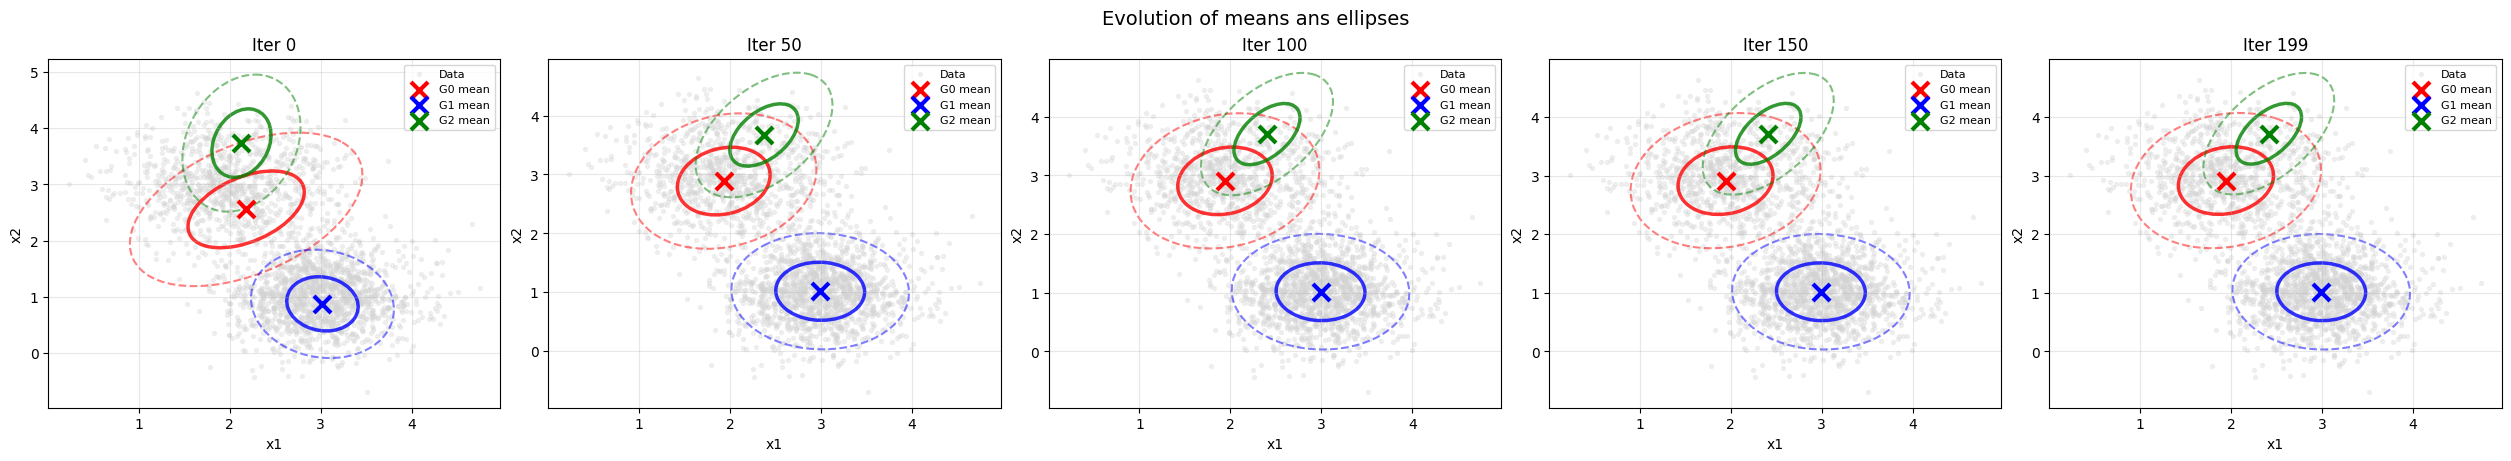

K0 = 4
2400 2
Iteration 1, Log Likelihood: -425.0218093112028
Iteration 51, Log Likelihood: -802.1444609487463
Iteration 101, Log Likelihood: -831.2838518887789
Iteration 151, Log Likelihood: -845.3538849600197
Iteration 200, Log Likelihood: -853.6047013548944


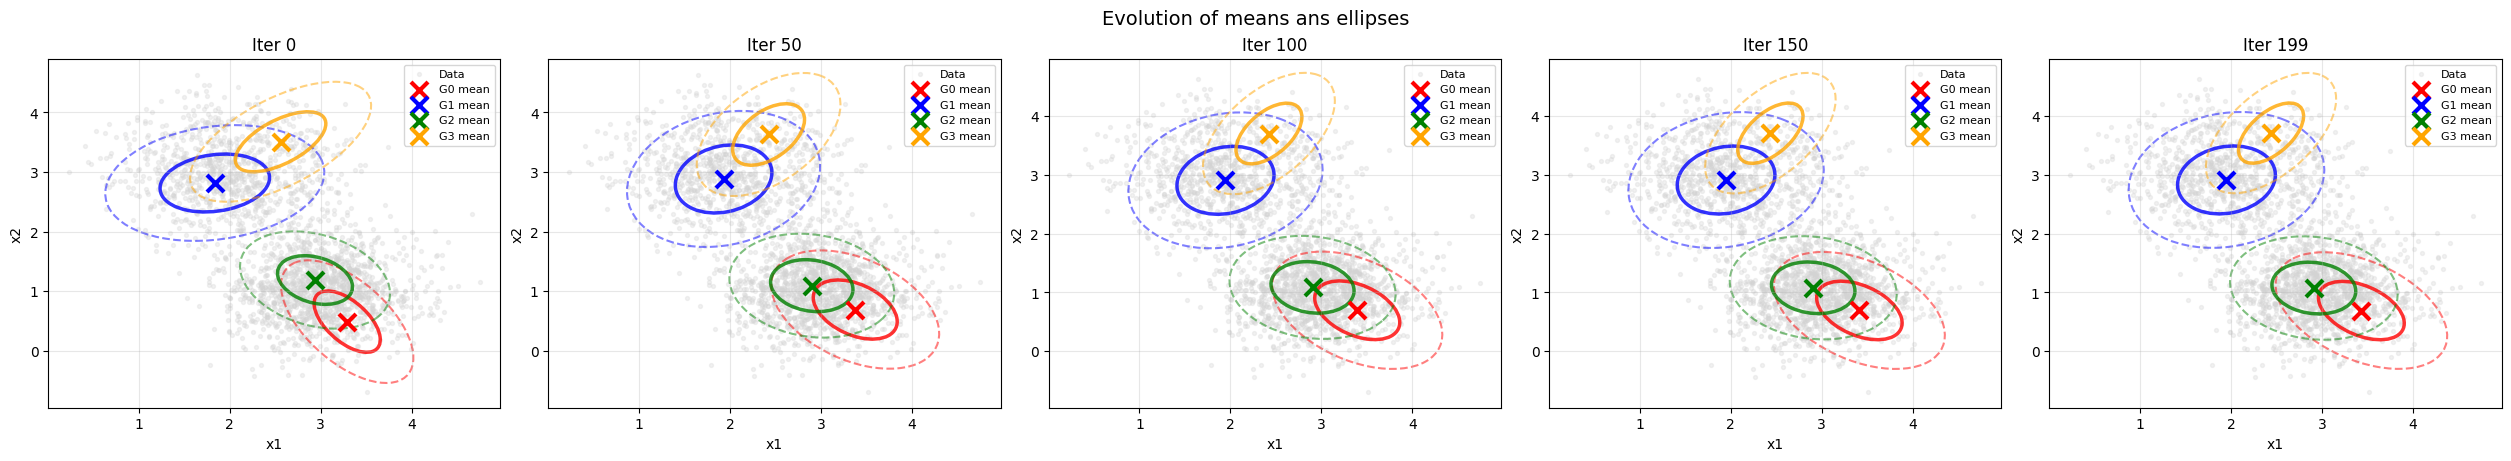

Training models for class 1
K1 = 1
4800 2
Iteration 1, Log Likelihood: -17259.82784068372
Convergence reached.


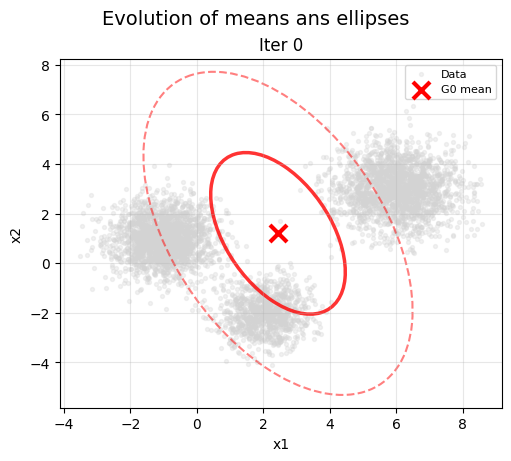

K1 = 2
4800 2
Iteration 1, Log Likelihood: -11815.135841941134
Convergence reached.


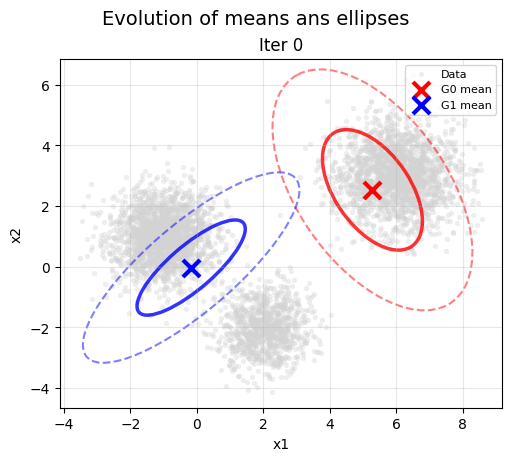

K1 = 3
4800 2
Iteration 1, Log Likelihood: -9070.222164141247
Convergence reached.


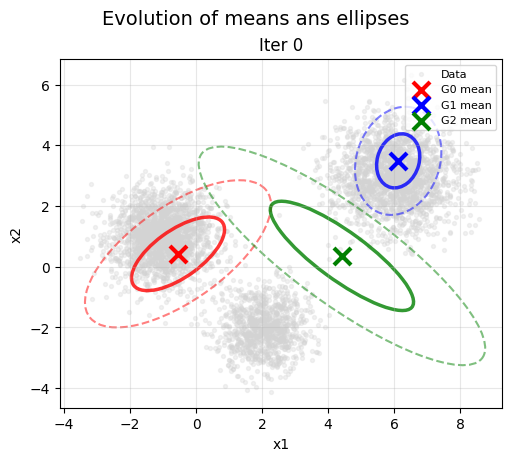

K1 = 4
4800 2
Iteration 1, Log Likelihood: -7729.475545628472
Iteration 51, Log Likelihood: -6682.654054282905
Iteration 101, Log Likelihood: -6692.589325683433
Iteration 151, Log Likelihood: -6696.185686122963
Iteration 200, Log Likelihood: -6696.209315405524


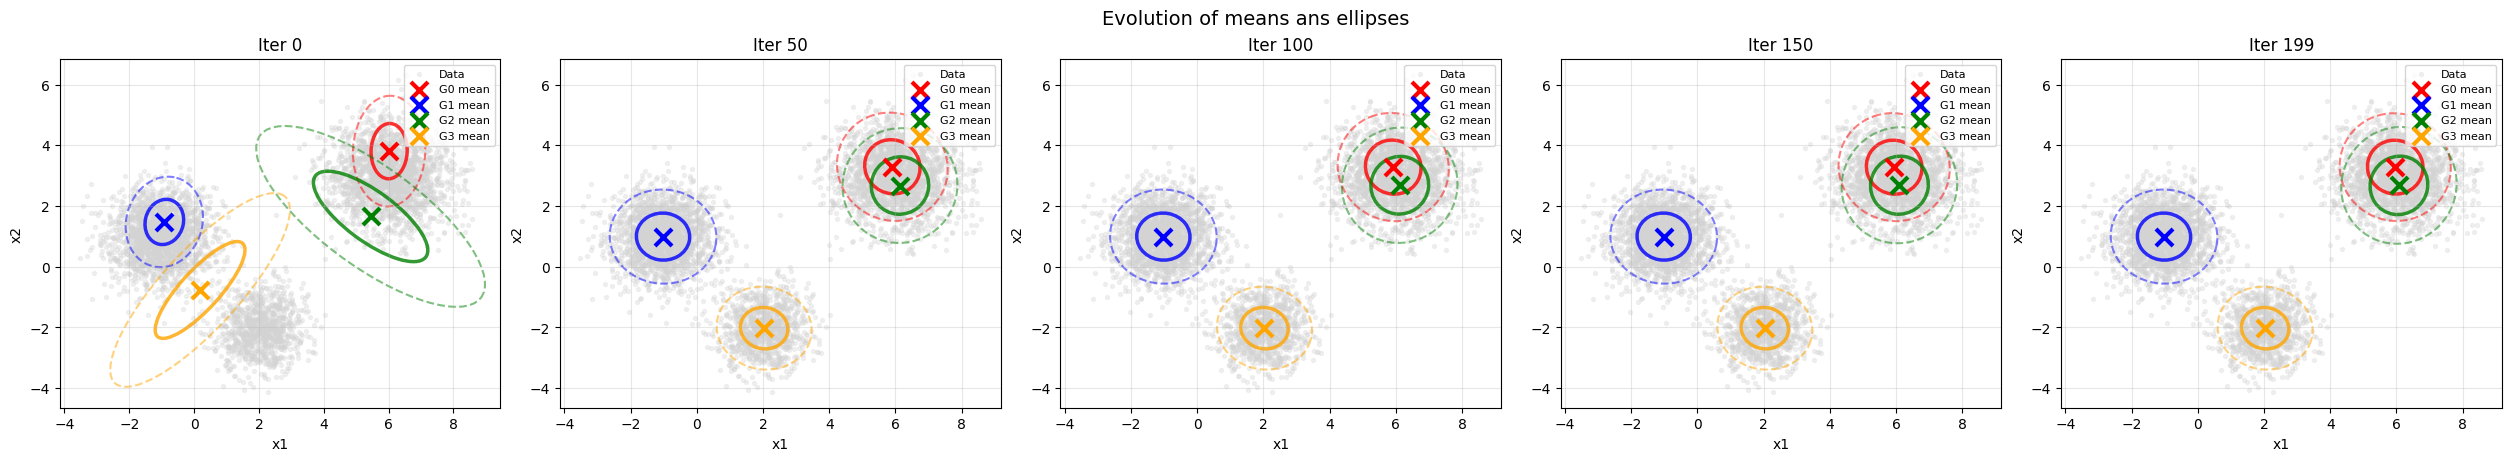

Evaluating combinations

Evaluating combination: K0=1, K1=1
Accuracy en validación: 0.9775

Evaluating combination: K0=1, K1=2
Accuracy en validación: 0.9898

Evaluating combination: K0=1, K1=3
Accuracy en validación: 0.9888

Evaluating combination: K0=1, K1=4
Accuracy en validación: 0.9892

Evaluating combination: K0=2, K1=1
Accuracy en validación: 0.9765

Evaluating combination: K0=2, K1=2
Accuracy en validación: 0.9919

Evaluating combination: K0=2, K1=3
Accuracy en validación: 0.9923

Evaluating combination: K0=2, K1=4
Accuracy en validación: 0.9919

Evaluating combination: K0=3, K1=1
Accuracy en validación: 0.9765

Evaluating combination: K0=3, K1=2
Accuracy en validación: 0.9919

Evaluating combination: K0=3, K1=3
Accuracy en validación: 0.9921

Evaluating combination: K0=3, K1=4
Accuracy en validación: 0.9921

Evaluating combination: K0=4, K1=1
Accuracy en validación: 0.9760

Evaluating combination: K0=4, K1=2
Accuracy en validación: 0.9917

Evaluating combination: K0=4, K1=3
Ac

In [30]:
df_c0_train = df_train[df_train['label'] == 0]
df_c1_train = df_train[df_train['label'] == 1]

df_c0_val = df_val[df_val['label'] == 0]
df_c1_val = df_val[df_val['label'] == 1]

number_gaussians = [1, 2, 3, 4]
k0_models = []
print("Training models for class 0")
for k0 in number_gaussians:
    print(f'K0 = {k0}')
    gmm0 = train(df_train[df_train['label'] == 0], K=k0, max_iter=200, tol=1e-6, show_plot=True)
    k0_models.append((k0, gmm0[:3])) 

k1_models = []
print("Training models for class 1")
for k1 in number_gaussians:
    print(f'K1 = {k1}')
    gmm1 = train(df_train[df_train['label'] == 1], K=k1, max_iter=200, tol=1e-6, show_plot=True)
    k1_models.append((k1, gmm1[:3]))

val_data = df_val.drop(columns='label').values
y_val_true = df_val['label'].values

best_score = 0
best_combination = (0, 0)

print("Evaluating combinations")
total_combinations = len(k0_models) * len(k1_models)
for idx in range(total_combinations):
    i = idx // len(k1_models) 
    j = idx % len(k1_models)   

    k0, gmm0 = k0_models[i]
    k1, gmm1 = k1_models[j]

    gmm_models = [
        (0, gmm0[:3]),
        (1, gmm1[:3]),
    ]

    print(f'\nEvaluating combination: K0={k0}, K1={k1}')
    y_val_pred = predict_class(val_data, gmm0, gmm1)
    acc = accuracy_score(y_val_true, y_val_pred)
    print(f'Accuracy en validación: {acc:.4f}')

    if acc > best_score:
        best_score = acc
        best_combination = (k0, k1)

print(f'\n>> Best combination: K0={best_combination[0]}, K1={best_combination[1]}, Acc={best_score:.4f}')




>> Retraining models with the full training set...
4000 2
Iteration 1, Log Likelihood: -4052.170702117828
Convergence reached.


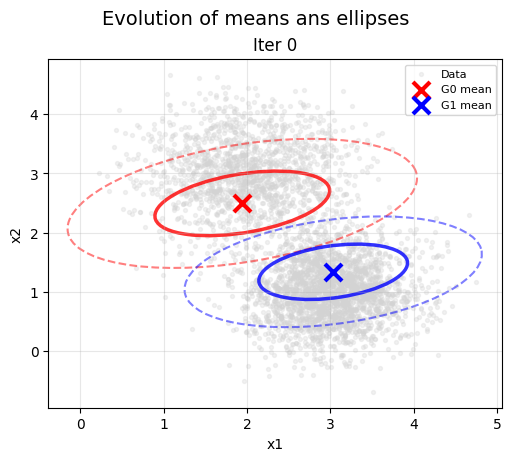

8000 2
Iteration 1, Log Likelihood: -12253.375485075707
Convergence reached.


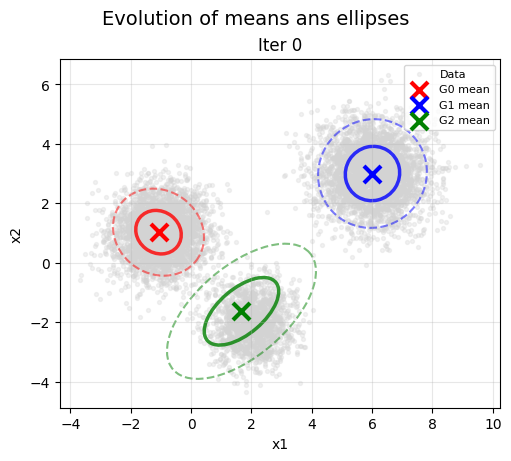


>> Results in test:
Accuracy: 0.9923333333333333
Precision: 0.9974836436839456
Recall: 0.991


In [31]:
# -------- Retrain models with full training set ----------
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
df_c0_full = df_full_train[df_full_train['label'] == 0]
df_c1_full = df_full_train[df_full_train['label'] == 1]

print("\n>> Retraining models with the full training set...")

gmm0_final = train(df_c0_full, K=best_combination[0], max_iter=200, tol=1e-6)
gmm1_final = train(df_c1_full, K=best_combination[1], max_iter=200, tol=1e-6)

# -------- Final evaluation on test set ----------
X_test = df_test.drop(columns='label').values
y_test = df_test['label'].values

y_pred = predict_class(X_test, gmm0_final[:3], gmm1_final[:3])

print("\n>> Results in test:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

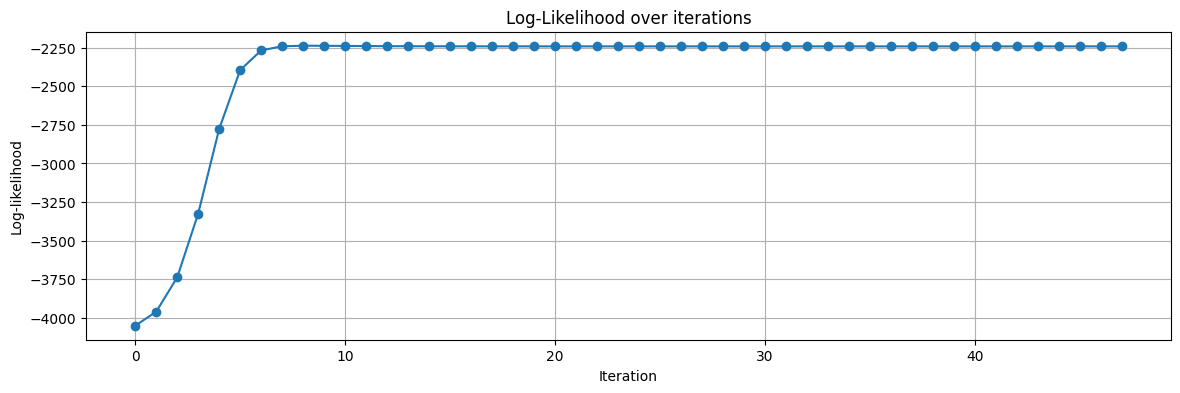

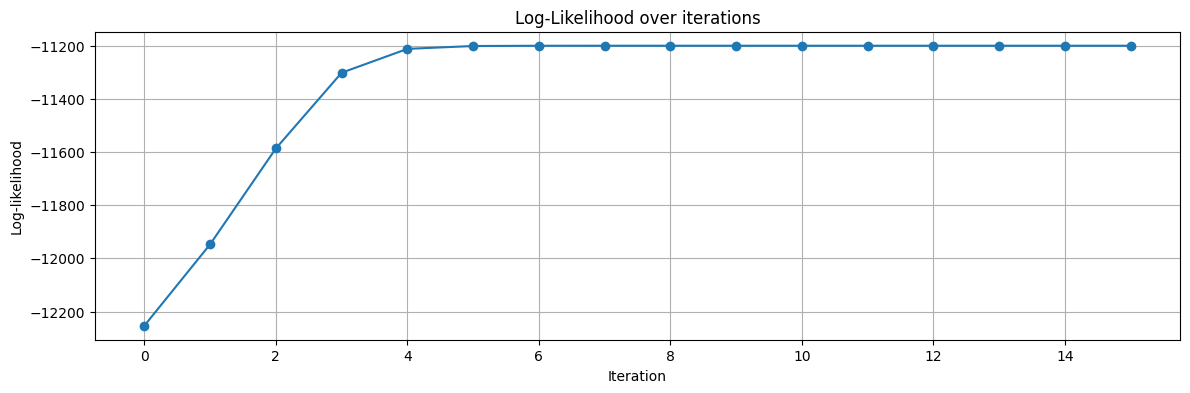

In [32]:
plot_likelihood(gmm0_final[3])
plot_likelihood(gmm1_final[3])

# PART 1.2

In [33]:
df = create_dataframe('exercise1_5.mat')
df_train, df_test = split_data(df, test_size=0.2, random_state=42)
df_train, df_val = split_data(df_train, test_size=0.4, random_state=42)
print("Training set shape:", df_train.shape)
print("Validation set shape:", df_val.shape)
print("Test set shape:", df_test.shape)

Keys:  dict_keys(['__header__', '__version__', '__globals__', 'C0', 'C1', 'C2'])
Clases encontradas: ['C0', 'C1', 'C2']
Clase C0 shape: (20000, 5)
Clase C1 shape: (30000, 5)
Clase C2 shape: (45000, 5)
Training set shape: (45600, 6)
Validation set shape: (30400, 6)
Test set shape: (19000, 6)


In [34]:
df_train

,x1,x2,x3,x4,x5,label
0,0.893832,0.818927,0.938829,0.211046,-0.712077,0
1,2.711551,4.528087,2.097120,-3.815624,-9.794358,0
2,3.774817,3.859910,-1.378970,-0.867767,-4.948126,0
3,3.904874,4.544037,4.175532,-7.940621,-7.187875,0
4,-0.460258,0.950637,4.014515,-1.812416,0.383505,0
...,...,...,...,...,...,...
45595,6.136665,-9.443467,0.426931,-1.302772,1.536637,2
45596,1.742044,-7.563709,1.561677,5.771969,1.291619,2
45597,-2.736733,6.023864,3.485346,-0.872121,0.696392,2
45598,-1.250684,9.570336,-2.309250,1.620227,5.830975,2


In [35]:
def predict_class(X, gmm_models):
    N = X.shape[0]
    n_classes = len(gmm_models)
    log_likelihoods = np.zeros((N, n_classes))
    
    for i, (class_label, (mu, cov, pi)) in enumerate(gmm_models):
        log_likelihoods[:, i] = compute_likelihood(X, mu, cov, pi)
    
    predictions = np.argmax(log_likelihoods, axis=1)
    return predictions


def compute_likelihood(X, mu, cov, pi):
    N, D = X.shape
    K = len(pi)
    component_likelihoods = np.zeros((N, K))

    for k in range(K):
        diff = X - mu[k] 
        cov_reg = cov[k] + np.eye(D) * 1e-6
        inv_cov = np.linalg.inv(cov_reg)
        det_cov = np.linalg.det(cov_reg)
        
        if det_cov <= 0:
            det_cov = 1e-6
        
        norm_const = 1. / np.sqrt((2 * np.pi) ** D * det_cov)
        exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
        exponent = np.clip(exponent, -500, 500)
        
        component_likelihoods[:, k] = pi[k] * norm_const * np.exp(exponent)
    total_likelihoods = np.sum(component_likelihoods, axis=1)
        
    return np.log(np.maximum(total_likelihoods, 1e-10))

In [36]:
def evaluate_predictions(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec}")
    print(f"Recall   : {rec}")

def accuracy_score(y_true, y_pred):
    correct = (y_true == y_pred).sum()
    total = len(y_true)
    return correct / total

def precision_score(y_true, y_pred):
    # Precision = TP / (TP + FP)
    classes = np.unique(np.concatenate((y_true, y_pred)))
    precisions = []
    for cls in classes:
        tp = ((y_pred == cls) & (y_true == cls)).sum()
        fp = ((y_pred == cls) & (y_true != cls)).sum()
        if tp + fp == 0:
            precisions.append(0.0)
        else:
            precisions.append(tp / (tp + fp))
    return precisions

def recall_score(y_true, y_pred):
    # Recall = TP / (TP + FN)
    classes = np.unique(np.concatenate((y_true, y_pred)))
    recalls = []
    for cls in classes:
        tp = ((y_pred == cls) & (y_true == cls)).sum()
        fn = ((y_pred != cls) & (y_true == cls)).sum()
        if tp + fn == 0:
            recalls.append(0.0)
        else:
            recalls.append(tp / (tp + fn))
    return recalls

In [37]:
feature_cols = [col for col in df_train.columns if col != 'label']

# convert from numpy arrays to pandas DataFrames
X_c0_train = df_train[df_train['label'] == 0][feature_cols].copy()
X_c1_train = df_train[df_train['label'] == 1][feature_cols].copy()
X_c2_train = df_train[df_train['label'] == 2][feature_cols].copy()

X_c0_val = df_val[df_val['label'] == 0][feature_cols].values
X_c1_val = df_val[df_val['label'] == 1][feature_cols].values
X_c2_val = df_val[df_val['label'] == 2][feature_cols].values

val_data = df_val[feature_cols].values
y_val_true = df_val['label'].values

number_gaussians = [2, 3, 4]

k0_models, k1_models, k2_models = [], [], []
print("Entrenando modelos para la clase 0")
for k0 in number_gaussians:
    print(f"K0 = {k0}")
    gmm0 = train(X_c0_train, K=k0, max_iter=100, tol=1e-6, show_plot=False)
    k0_models.append((k0, gmm0[:3]))  # mu, cov, pi

print("\nEntrenando modelos para la clase 1")
for k1 in number_gaussians:
    print(f"K1 = {k1}")
    gmm1 = train(X_c1_train, K=k1, max_iter=100, tol=1e-6, show_plot=False)
    k1_models.append((k1, gmm1[:3]))

print("\nEntrenando modelos para la clase 2")
for k2 in number_gaussians:
    print(f"K2 = {k2}")
    gmm2 = train(X_c2_train, K=k2, max_iter=100, tol=1e-6, show_plot=False)
    k2_models.append((k2, gmm2[:3]))

# Evaluar todas las combinaciones de modelos
print("\nEvaluando combinaciones de modelos")
best_score = 0
best_combination = (0, 0, 0)
total_combinations = len(k0_models) * len(k1_models) * len(k2_models)

for idx in range(total_combinations):
    i = idx // (len(k1_models) * len(k2_models))
    j = (idx // len(k2_models)) % len(k1_models)
    k = idx % len(k2_models)

    k0, gmm0 = k0_models[i]
    k1, gmm1 = k1_models[j]
    k2, gmm2 = k2_models[k]

    mu0, cov0, pi0 = gmm0
    mu1, cov1, pi1 = gmm1
    mu2, cov2, pi2 = gmm2

    print(f"\nEvaluando combinación: K0={k0}, K1={k1}, K2={k2}")

    gmm_models = [
        (0, (mu0, cov0, pi0)),
        (1, (mu1, cov1, pi1)),
        (2, (mu2, cov2, pi2))
    ]

    y_val_pred = predict_class(val_data, gmm_models)
    acc = accuracy_score(y_val_true, y_val_pred)
    print(f"Accuracy en validación: {acc:.4f}")

    if acc > best_score:
        best_score = acc
        best_combination = (k0, k1, k2)

print(f"\n>> Mejor combinación: K0={best_combination[0]}, K1={best_combination[1]}, K2={best_combination[2]}, Acc={best_score:.4f}")


Entrenando modelos para la clase 0
K0 = 2
9600 5
Iteration 1, Log Likelihood: -75434.2941921181
Convergence reached.
K0 = 3
9600 5
Iteration 1, Log Likelihood: -60636.57496277096
Iteration 51, Log Likelihood: -62276.38263464046
Iteration 100, Log Likelihood: -62366.47042019527
K0 = 4
9600 5
Iteration 1, Log Likelihood: -59166.45398615666
Iteration 51, Log Likelihood: -59454.78583808667
Iteration 100, Log Likelihood: -59429.472630704586

Entrenando modelos para la clase 1
K1 = 2
14400 5
Iteration 1, Log Likelihood: -153352.59036478295
Convergence reached.
K1 = 3
14400 5
Iteration 1, Log Likelihood: -105398.64251600849
Convergence reached.
K1 = 4
14400 5
Iteration 1, Log Likelihood: -100891.64019682663
Convergence reached.

Entrenando modelos para la clase 2
K2 = 2
21600 5
Iteration 1, Log Likelihood: -194046.19121955417
Convergence reached.
K2 = 3
21600 5
Iteration 1, Log Likelihood: -163584.41127032207
Convergence reached.
K2 = 4
21600 5
Iteration 1, Log Likelihood: -156774.2840885225


In [38]:
# -------- Retrain models with full training set ----------
df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
df_c0_full = df_full_train[df_full_train['label'] == 0][feature_cols].copy()
df_c1_full = df_full_train[df_full_train['label'] == 1][feature_cols].copy()
df_c2_full = df_full_train[df_full_train['label'] == 2][feature_cols].copy()

print("\n>> Retraining models with the full training set...")

gmm0_final = train(df_c0_full, K=best_combination[0], max_iter=200, tol=1e-6, show_plot=False)
gmm1_final = train(df_c1_full, K=best_combination[1], max_iter=200, tol=1e-6, show_plot=False)
gmm2_final = train(df_c2_full, K=best_combination[2], max_iter=200, tol=1e-6, show_plot=False)

# -------- Final evaluation on test set ----------
X_test = df_test[feature_cols].values
y_test = df_test['label'].values

gmm_models_final = [
    (0, gmm0_final[:3]),
    (1, gmm1_final[:3]),
    (2, gmm2_final[:3])
]

y_pred = predict_class(X_test, gmm_models_final)

print("\n>> Results in test:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred)) 
print("Recall:", recall_score(y_test, y_pred)) 



>> Retraining models with the full training set...
16000 5
Iteration 1, Log Likelihood: -99047.45360943116
Iteration 51, Log Likelihood: -100251.5389210351
Iteration 101, Log Likelihood: -100335.91939814368
Iteration 151, Log Likelihood: -100391.13035434118
Iteration 200, Log Likelihood: -100449.58567636725
24000 5
Iteration 1, Log Likelihood: -172504.87208188494
Convergence reached.
36000 5
Iteration 1, Log Likelihood: -267232.34929945285
Iteration 51, Log Likelihood: -273446.2917627433
Iteration 101, Log Likelihood: -273841.0355588588
Iteration 151, Log Likelihood: -273954.50632246607
Iteration 200, Log Likelihood: -274005.9629700526

>> Results in test:
Accuracy: 0.9655789473684211
Precision: [np.float64(0.8739420935412027), np.float64(0.9956652217405801), np.float64(0.9927161654135338)]
Recall: [np.float64(0.981), np.float64(0.9953333333333333), np.float64(0.9388888888888889)]
